# Walk-Forward Multi-Asset Validation

Notebooks 1 and 2 fit a linear model on one train/test split of one symbol's one year
of data. `results/001_simple_linear.md` flagged exactly why that isn't trustworthy:
one split can't tell a real edge apart from luck, no baseline was checked, and at
least one "winning" model turned out to be a constant directional bet in disguise.

This notebook addresses each point directly, still one asset at a time under the hood,
but now:

1. Walk-forward validated over 5 years, with the train/test grid itself shifted and
   swept to check whether results are an artifact of where the grid happens to sit.
2. Benchmarked against buy-and-hold (and always-long/short/flat, and random) over
   multiple periods, not just the model's own test window.
3. Every fitted linear model's weight/bias is inspected for the "it's just a constant
   bet" failure mode notebook 1 already found once.
4. Run across 6 symbols (BTC, ETH, DOGE, SOL, XRP, BNB) with one config frozen from
   the BTC section — not re-tuned per symbol, which would just reintroduce the
   overfitting notebook 2 demonstrated.

## 0. Data source: klines, not raw trades

Notebooks 1 and 2 download raw Binance trades (`data.download_date_range`) and
aggregate them into bars at load time. One symbol-year of ticks is ~12 GB; 5 years
of 6 symbols that way would be several hundred GB and hours of downloading, just to
reconstruct bars Binance already publishes directly as **klines** (pre-aggregated
OHLCV files, ~30-100 KB per symbol-month).

Before relying on klines for this notebook, we check they agree with the
tick-aggregated bars notebooks 1/2 already produced, using the cached 2025 BTC 1h
data both pipelines can produce.

In [1]:
import sys
from datetime import UTC, datetime

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch
from scipy import stats
from torch import nn

sys.path.insert(0, "..")
import data
import research

research.set_seed(123)
pl.Config.set_tbl_cols(20)
pl.Config.set_tbl_width_chars(220)

polars.config.Config

In [2]:
tick_1h = research.load_ohlc_timeseries_range(
    "BTCUSDT",
    "1h",
    datetime(2025, 1, 1, tzinfo=UTC),
    datetime(2026, 1, 1, tzinfo=UTC),
    data_path="cache",
)
kline_1h = data.download_klines_range(
    "BTCUSDT",
    "1h",
    datetime(2025, 1, 1, tzinfo=UTC),
    datetime(2026, 1, 1, tzinfo=UTC),
    cache_dir="cache",
    download_dir="tmp",
)

joined = tick_1h.select("datetime", "open", "high", "low", "close", "volume").join(
    kline_1h.select("datetime", "open", "high", "low", "close", "volume"),
    on="datetime",
    how="inner",
    suffix="_kl",
)

print(
    f"tick-aggregated bars: {len(tick_1h)}, klines: {len(kline_1h)}, overlap: {len(joined)}"
)
for col in ["open", "high", "low", "close", "volume"]:
    diff = (joined[col] - joined[f"{col}_kl"]).abs()
    reldiff = (diff / joined[col].abs()).drop_nans()
    print(
        f"{col:8s} max abs diff={diff.max():.6f}  median rel diff={reldiff.median():.2e}  max rel diff={reldiff.max():.2e}"
    )

missing_in_kline = tick_1h.join(kline_1h, on="datetime", how="anti").sort("datetime")
print(f"\nRows in tick-aggregated bars but not in klines: {len(missing_in_kline)}")
if len(missing_in_kline):
    print(missing_in_kline.select("datetime").to_series().to_list())

tick-aggregated bars: 8784, klines: 8761, overlap: 8761
open     max abs diff=0.100000  median rel diff=0.00e+00  max rel diff=8.80e-07
high     max abs diff=60.300000  median rel diff=0.00e+00  max rel diff=5.25e-04
low      max abs diff=109.800000  median rel diff=0.00e+00  max rel diff=1.14e-03
close    max abs diff=0.100000  median rel diff=0.00e+00  max rel diff=8.80e-07
volume   max abs diff=15140.008000  median rel diff=0.00e+00  max rel diff=3.95e+00

Rows in tick-aggregated bars but not in klines: 23
[datetime.datetime(2026, 1, 1, 1, 0), datetime.datetime(2026, 1, 1, 2, 0), datetime.datetime(2026, 1, 1, 3, 0), datetime.datetime(2026, 1, 1, 4, 0), datetime.datetime(2026, 1, 1, 5, 0), datetime.datetime(2026, 1, 1, 6, 0), datetime.datetime(2026, 1, 1, 7, 0), datetime.datetime(2026, 1, 1, 8, 0), datetime.datetime(2026, 1, 1, 9, 0), datetime.datetime(2026, 1, 1, 10, 0), datetime.datetime(2026, 1, 1, 11, 0), datetime.datetime(2026, 1, 1, 12, 0), datetime.datetime(2026, 1, 1, 13, 0),

**Verdict:** open/close match to ~1e-6 relative difference (rounding only). High/low/volume
differ by up to ~0.1%, most likely from differing trade-type inclusion between the two
Binance feeds (e.g. liquidation/insurance-fund trades handled differently) — worth knowing
about, not a blocker. The rows only in the tick-aggregated set are trailing hours of
2026-01-01, an edge effect of the tick downloader pulling one extra day past `end_date`,
not a real discrepancy. Klines are used for the rest of this notebook.

## 1. Configuration

5 years (2021-07-01 to 2026-07-01) across four bar intervals, six symbols. All six
have listed futures well before the window start (checked against Binance's archive
directly, not assumed).

In [3]:
SYMBOLS = ["BTCUSDT", "ETHUSDT", "DOGEUSDT", "SOLUSDT", "XRPUSDT", "BNBUSDT"]
INTERVALS = ["1h", "4h", "12h", "1d"]
BARS_PER_DAY = {"1h": 24, "4h": 6, "12h": 2, "1d": 1}

START = datetime(2021, 7, 1, tzinfo=UTC)
END = datetime(2026, 7, 1, tzinfo=UTC)

# e.g. VIP 4 level on binance, same assumption as notebooks 1 & 2
MAKER_FEE = 0.0001
TAKER_FEE = 0.0003
EDGE_THRESHOLD = TAKER_FEE * 2  # round-trip cost; don't trade an edge smaller than this

MOMENTUM_WINDOWS = [2, 3, 5, 8, 13, 21, 34]
MEAN_REV_LAGS = 4
MAX_LOOKBACK = max(MEAN_REV_LAGS, max(MOMENTUM_WINDOWS))


class LinearModel(nn.Module):
    def __init__(self, input_features):
        super().__init__()
        self.linear = nn.Linear(input_features, 1)

    def forward(self, x):
        return self.linear(x)


class TanhLinearModel(nn.Module):
    """Linear score passed through tanh, bounding y_pred to (-1, 1) instead of an
    unbounded score. tanh is monotonic and sign-preserving, so the same weight/bias
    degenerate-bet check applies unchanged."""

    def __init__(self, input_features):
        super().__init__()
        self.linear = nn.Linear(input_features, 1)

    def forward(self, x):
        return torch.tanh(self.linear(x))


def load_bars(sym, interval):
    return data.download_klines_range(
        sym, interval, START, END, cache_dir="cache", download_dir="tmp"
    )


def add_mean_reversion_features(df, no_lags=MEAN_REV_LAGS, forecast_horizon=1):
    df = research.add_log_return_features(
        df, "close", forecast_horizon, max_no_lags=no_lags
    )
    feature_cols = [f"close_log_return_lag_{i}" for i in range(1, no_lags + 1)]
    return df, feature_cols


def add_momentum_features(df, momentum_windows=MOMENTUM_WINDOWS, forecast_horizon=1):
    target = "close_log_return"
    if target not in df.columns:
        df = df.with_columns(
            (pl.col("close") / pl.col("close").shift(1)).log().alias(target)
        )
    feature_cols = []
    for w in momentum_windows:
        name = f"momentum_{w}"
        df = df.with_columns(
            pl.col(target)
            .rolling_sum(window_size=w)
            .shift(forecast_horizon)
            .alias(name)
        )
        feature_cols.append(name)
    return df, feature_cols


def run_walk_forward_config(
    df,
    features,
    target,
    model_cls,
    annualized_rate,
    train_bars,
    test_bars,
    mode="rolling",
    embargo_bars=0,
    origin_offset=0,
    step_bars=None,
    loss=None,
    threshold=0.0,
    no_epochs=500,
    lr=5e-4,
):
    """Glue config onto research.walk_forward_splits/walk_forward_run and add the
    degenerate-fold tally, so every section below can just describe *what* config
    it's running rather than re-deriving the plumbing."""
    splits = research.walk_forward_splits(
        len(df),
        train_bars=train_bars,
        test_bars=test_bars,
        step_bars=step_bars,
        mode=mode,
        embargo_bars=embargo_bars,
        origin_offset=origin_offset,
    )
    if not splits:
        return None
    result = research.walk_forward_run(
        df,
        features,
        target,
        model_cls,
        splits,
        annualized_rate,
        loss=loss,
        lr=lr,
        no_epochs=no_epochs,
        threshold=threshold,
    )
    summary = research.stitched_metrics(result["stitched_trades"], annualized_rate)
    folds = result["folds"]
    summary["no_folds"] = len(splits)
    if len(folds) and "lm_is_degenerate" in folds.columns:
        summary["no_degenerate_folds"] = int(folds["lm_is_degenerate"].sum())
        summary["frac_degenerate_folds"] = summary["no_degenerate_folds"] / len(folds)
    else:
        summary["no_degenerate_folds"] = 0
        summary["frac_degenerate_folds"] = 0.0
    return {"config_summary": summary, "result": result}

In [4]:
# Data-quality check: any missing bars per symbol/interval (real gaps in Binance's
# archive, e.g. exchange data outages, not something to paper over).
for sym in SYMBOLS:
    df_check = load_bars(sym, "1h")
    full_range = pl.datetime_range(
        df_check["datetime"].min(),
        df_check["datetime"].max(),
        interval="1h",
        eager=True,
    )
    missing = pl.DataFrame({"datetime": full_range}).join(
        df_check, on="datetime", how="anti"
    )
    print(
        f"{sym:10s} 1h bars: {len(df_check):6d}  missing: {len(missing):4d} ({len(missing) / len(full_range):.3%})"
    )

BTCUSDT    1h bars:  43824  missing:    0 (0.000%)
ETHUSDT    1h bars:  43824  missing:    0 (0.000%)
DOGEUSDT   1h bars:  43824  missing:    0 (0.000%)
SOLUSDT    1h bars:  43704  missing:  120 (0.274%)
XRPUSDT    1h bars:  43704  missing:  120 (0.274%)
BNBUSDT    1h bars:  43824  missing:    0 (0.000%)


SOL and XRP are each missing the same 120 hours (scattered days in Feb-Apr 2022) -
a real gap in Binance's own klines archive for those two symbols, not a bug in the
downloader. It's ~0.27% of bars, early in the window; not corrected for, just noted.

## 2. Single-asset (BTC) walk-forward baseline

One config, illustrated in detail: 1h bars, 180-day train / 30-day test, rolling
(fixed-length train window), embargoed by the feature lookback so no test-fold
feature can see across the boundary into train data. Single feature
(`close_log_return_lag_1`) to match notebook 1's simplest case.

In [5]:
btc_1h = load_bars("BTCUSDT", "1h")
btc_1h_mr, mr_features = add_mean_reversion_features(btc_1h)
btc_1h_mr = btc_1h_mr.drop_nulls()

rate_1h = research.sharpe_to_annualized_rate("1h")
baseline_train_bars = 180 * BARS_PER_DAY["1h"]
baseline_test_bars = 30 * BARS_PER_DAY["1h"]

baseline = run_walk_forward_config(
    btc_1h_mr,
    [mr_features[0]],
    "close_log_return",
    LinearModel,
    rate_1h,
    train_bars=baseline_train_bars,
    test_bars=baseline_test_bars,
    mode="rolling",
    embargo_bars=MEAN_REV_LAGS,
    loss=nn.L1Loss(),
    threshold=EDGE_THRESHOLD,
    no_epochs=2000,
)
print(baseline["config_summary"])

{'label': 'strategy', 'no_bars': 38880, 'total_log_return': 0.880255937576294, 'compound_return': 1.4115168252133339, 'std': 0.0028281386476010084, 'sharpe': 0.7492627139738045, 'max_drawdown': -0.4591313898563385, 'no_trades': 4326, 'frac_time_in_market': 0.11126543209876544, 'win_rate': 0.5783633841886269, 'no_folds': 54, 'no_degenerate_folds': 0, 'frac_degenerate_folds': 0.0}


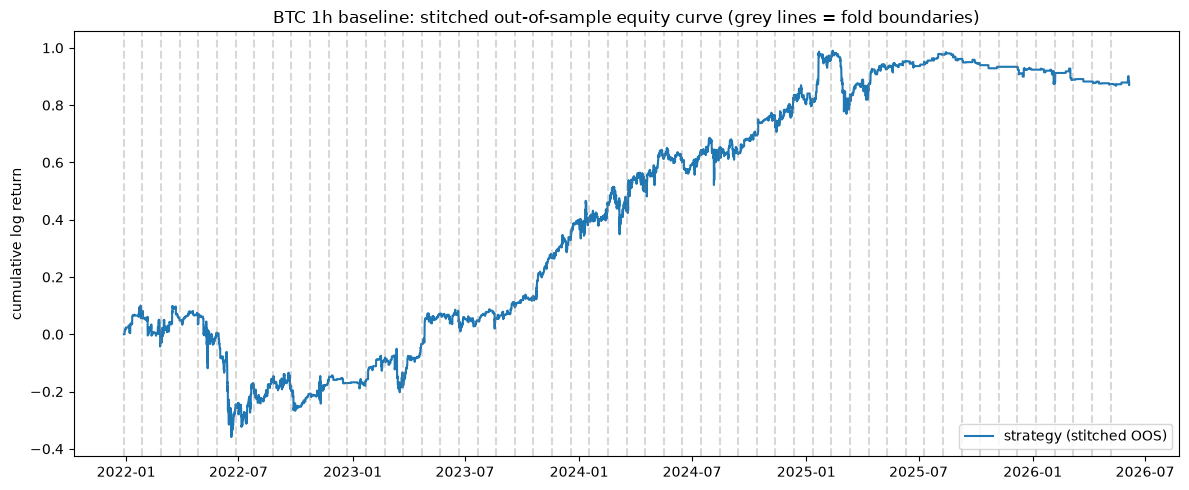

In [6]:
folds_df = baseline["result"]["folds"]
trades = baseline["result"]["stitched_trades"]

fold_starts = (
    trades.group_by("fold").agg(pl.col("datetime").min().alias("start")).sort("fold")
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(
    trades["datetime"],
    trades["equity_curve"],
    label="strategy (stitched OOS)",
    color="tab:blue",
)
for dt in fold_starts["start"]:
    ax.axvline(dt, color="grey", linestyle="--", alpha=0.3)
ax.set_title(
    "BTC 1h baseline: stitched out-of-sample equity curve (grey lines = fold boundaries)"
)
ax.set_ylabel("cumulative log return")
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
# Per-fold weight/bias inspection: a fold is flagged DEGENERATE when the bias term
# alone determines every position regardless of the feature value in that fold, i.e.
# it's a constant long/short bet wearing an ML costume, not a fitted relationship.
# This is exactly the failure mode results/001_simple_linear.md flagged in notebook 1
# ("the always short model... it's basically a constant short bet the whole window").
for row in folds_df.iter_rows(named=True):
    print(
        f"Fold {row['fold']:2d} [{row['test_start_date']} -> {row['test_end_date']}] "
        f"sharpe={row['sharpe']:+6.2f}  {row['lm_verdict']}"
    )

Fold  0 [2021-12-28T09:00:00.000000 -> 2022-01-27T08:00:00.000000] sharpe= +3.12  responsive (|bias|=8.037e-05 <= max|w.x|=0.001869, 327 sign flips)
Fold  1 [2022-01-27T09:00:00.000000 -> 2022-02-26T08:00:00.000000] sharpe= -3.62  responsive (|bias|=5.311e-05 <= max|w.x|=0.002082, 380 sign flips)
Fold  2 [2022-02-26T09:00:00.000000 -> 2022-03-28T08:00:00.000000] sharpe= +3.05  responsive (|bias|=2.223e-06 <= max|w.x|=0.002844, 383 sign flips)
Fold  3 [2022-03-28T09:00:00.000000 -> 2022-04-27T08:00:00.000000] sharpe= -0.86  responsive (|bias|=1.228e-05 <= max|w.x|=0.001376, 398 sign flips)
Fold  4 [2022-04-27T09:00:00.000000 -> 2022-05-27T08:00:00.000000] sharpe= -0.87  responsive (|bias|=2.6e-05 <= max|w.x|=0.004701, 383 sign flips)
Fold  5 [2022-05-27T09:00:00.000000 -> 2022-06-26T08:00:00.000000] sharpe= -5.26  responsive (|bias|=5.328e-05 <= max|w.x|=0.003846, 378 sign flips)
Fold  6 [2022-06-26T09:00:00.000000 -> 2022-07-26T08:00:00.000000] sharpe= +1.84  responsive (|bias|=3.893e-

Read the lines above: **"constant SHORT"/"constant LONG"** means every bar in that
fold got the same position no matter what the feature said — that fold's Sharpe is a
directional bet's Sharpe, not evidence the model learned anything. **"responsive"**
means the feature's value was large enough, at least sometimes, to flip the
prediction's sign within the fold — the minimum bar for "this fold's number reflects
the model doing something."

## 3. Sweep the timeframes

Two things vary: the bar interval, and the train/test window size (including
expanding/"anchored" windows). Same single-feature config as the baseline, so this
isolates the effect of timeframe choice alone.

In [8]:
window_configs = [
    (90, 30, "rolling"),
    (180, 30, "rolling"),
    (180, 90, "rolling"),
    (365, 90, "rolling"),
    (365, 180, "rolling"),
    (90, 30, "anchored"),
    (180, 90, "anchored"),
]

timeframe_grid = []
for interval in INTERVALS:
    df_iv = load_bars("BTCUSDT", interval)
    df_iv, feats = add_mean_reversion_features(df_iv)
    df_iv = df_iv.drop_nulls()
    rate = research.sharpe_to_annualized_rate(interval)
    bpd = BARS_PER_DAY[interval]

    for train_days, test_days, mode in window_configs:
        run = run_walk_forward_config(
            df_iv,
            feats,
            "close_log_return",
            LinearModel,
            rate,
            train_bars=train_days * bpd,
            test_bars=test_days * bpd,
            mode=mode,
            embargo_bars=MEAN_REV_LAGS,
            loss=nn.L1Loss(),
            threshold=EDGE_THRESHOLD,
            no_epochs=300,
        )
        if run is None:
            continue
        s = run["config_summary"]
        s.update(
            {
                "interval": interval,
                "train_days": train_days,
                "test_days": test_days,
                "mode": mode,
            }
        )
        timeframe_grid.append(s)

timeframe_results = pl.DataFrame(timeframe_grid).sort("sharpe", descending=True)
timeframe_results.select(
    "interval",
    "train_days",
    "test_days",
    "mode",
    "no_folds",
    "sharpe",
    "compound_return",
    "max_drawdown",
    "frac_degenerate_folds",
    "no_trades",
)

interval,train_days,test_days,mode,no_folds,sharpe,compound_return,max_drawdown,frac_degenerate_folds,no_trades
str,i64,i64,str,i64,f64,f64,f64,f64,i64
"""1d""",90,30,"""rolling""",57,1.057506,12.069251,-0.807937,0.017544,1703
"""1h""",180,90,"""rolling""",18,0.905694,6.779711,-0.796158,0.0,38789
"""12h""",180,90,"""anchored""",18,0.887329,6.510035,-0.67914,0.0,3235
"""12h""",180,90,"""rolling""",18,0.79141,5.04155,-0.829058,0.0,3232
"""4h""",180,90,"""anchored""",18,0.620342,2.95397,-0.915716,0.0,9705
…,…,…,…,…,…,…,…,…,…
"""12h""",365,180,"""rolling""",8,-0.524395,-0.62741,-2.053514,0.0,2877
"""4h""",365,90,"""rolling""",16,-0.528186,-0.624515,-1.568322,0.0,8623
"""12h""",180,30,"""rolling""",54,-0.715337,-0.803295,-1.932791,0.0,3239


## 4. Shift the origin

Same baseline config (1h, 180d/30d, rolling), re-run with the fold grid's start
shifted by 0/7/14/21 days across each interval. If Sharpe swings wildly with the
shift alone, the result is a fold-alignment artifact rather than something robust to
where the walk-forward clock happens to start.

In [9]:
origin_shift_grid = []
for interval in INTERVALS:
    df_iv = load_bars("BTCUSDT", interval)
    df_iv, feats = add_mean_reversion_features(df_iv)
    df_iv = df_iv.drop_nulls()
    rate = research.sharpe_to_annualized_rate(interval)
    bpd = BARS_PER_DAY[interval]
    train_bars = 180 * bpd
    test_bars = 30 * bpd

    for offset_days in [0, 7, 14, 21]:
        run = run_walk_forward_config(
            df_iv,
            feats,
            "close_log_return",
            LinearModel,
            rate,
            train_bars=train_bars,
            test_bars=test_bars,
            mode="rolling",
            embargo_bars=MEAN_REV_LAGS,
            origin_offset=offset_days * bpd,
            loss=nn.L1Loss(),
            threshold=EDGE_THRESHOLD,
            no_epochs=300,
        )
        if run is None:
            continue
        s = run["config_summary"]
        s.update({"interval": interval, "offset_days": offset_days})
        origin_shift_grid.append(s)

origin_shift_results = pl.DataFrame(origin_shift_grid)
origin_shift_results.select(
    "interval",
    "offset_days",
    "no_folds",
    "sharpe",
    "compound_return",
    "frac_degenerate_folds",
)

interval,offset_days,no_folds,sharpe,compound_return,frac_degenerate_folds
str,i64,i64,f64,f64,f64
"""1h""",0,54,-1.293891,-0.946599,0.0
"""1h""",7,54,0.069136,0.169286,0.0
"""1h""",14,54,0.000087,0.000195,0.0
"""1h""",21,54,-0.624334,-0.756612,0.0
"""4h""",0,54,-0.221466,-0.388027,0.0
…,…,…,…,…,…
"""12h""",21,54,0.043337,0.102379,0.0
"""1d""",0,54,-0.067124,-0.142123,0.018519
"""1d""",7,54,-0.346096,-0.545801,0.037037


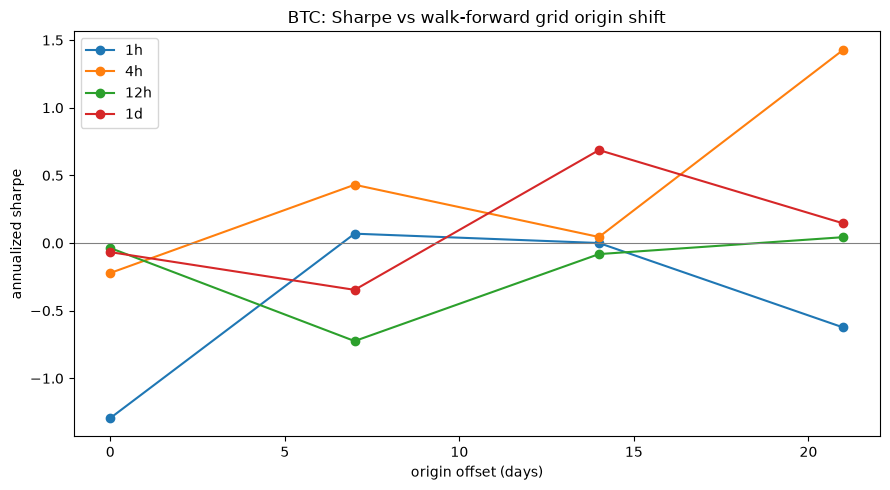

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
for interval in INTERVALS:
    sub = origin_shift_results.filter(pl.col("interval") == interval).sort(
        "offset_days"
    )
    ax.plot(sub["offset_days"], sub["sharpe"], marker="o", label=interval)
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_xlabel("origin offset (days)")
ax.set_ylabel("annualized sharpe")
ax.set_title("BTC: Sharpe vs walk-forward grid origin shift")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Try different things: features x loss x threshold x model

A pre-declared grid (not expanded after seeing results, so the trial count below is
honest) on 12h bars, 180d train / 90d test rolling — a coarser interval than the
sweep above, chosen so this larger grid finishes in a reasonable time. Fixed embargo
of `MAX_LOOKBACK` bars across all feature sets so results aren't confounded by
different embargo lengths.

In [11]:
df_12h = load_bars("BTCUSDT", "12h")
df_12h, mr_feats = add_mean_reversion_features(df_12h)
df_12h, mom_feats = add_momentum_features(df_12h)
df_12h = df_12h.drop_nulls()

feature_sets = {
    "mean_reversion": mr_feats,
    "momentum": mom_feats,
    "combined": mr_feats + mom_feats,
}
loss_fns = {"mse": nn.MSELoss(), "l1": nn.L1Loss(), "huber": nn.HuberLoss()}
thresholds = {"0": 0.0, "1x_taker": TAKER_FEE, "round_trip": TAKER_FEE * 2}
model_variants = {"linear": LinearModel, "tanh_linear": TanhLinearModel}

rate_12h = research.sharpe_to_annualized_rate("12h")
train_bars_12h = 180 * BARS_PER_DAY["12h"]
test_bars_12h = 90 * BARS_PER_DAY["12h"]

grid_results = []
trial_count = 0
for fname, feats in feature_sets.items():
    for lname, loss in loss_fns.items():
        for tname, thresh in thresholds.items():
            for mname, model_cls in model_variants.items():
                trial_count += 1
                run = run_walk_forward_config(
                    df_12h,
                    feats,
                    "close_log_return",
                    model_cls,
                    rate_12h,
                    train_bars=train_bars_12h,
                    test_bars=test_bars_12h,
                    mode="rolling",
                    embargo_bars=MAX_LOOKBACK,
                    loss=loss,
                    threshold=thresh,
                    no_epochs=300,
                )
                if run is None:
                    continue
                s = run["config_summary"]
                s.update(
                    {
                        "features": fname,
                        "loss": lname,
                        "threshold": tname,
                        "model": mname,
                    }
                )
                grid_results.append(s)

print(f"Trials in this grid: {trial_count}")
grid_df = pl.DataFrame(grid_results).sort("sharpe", descending=True)
grid_df.head(15).select(
    "features",
    "loss",
    "threshold",
    "model",
    "no_folds",
    "sharpe",
    "compound_return",
    "max_drawdown",
    "frac_degenerate_folds",
    "no_trades",
)

Trials in this grid: 54


features,loss,threshold,model,no_folds,sharpe,compound_return,max_drawdown,frac_degenerate_folds,no_trades
str,str,str,str,i64,f64,f64,f64,f64,i64
"""momentum""","""huber""","""1x_taker""","""tanh_linear""",17,0.756931,4.10907,-0.597777,0.0,3060
"""momentum""","""mse""","""0""","""linear""",17,0.732303,3.845208,-0.645268,0.0,3060
"""momentum""","""mse""","""round_trip""","""tanh_linear""",17,0.537855,2.187239,-0.835944,0.0,3059
"""combined""","""l1""","""0""","""tanh_linear""",17,0.474925,1.783201,-0.793446,0.0,3060
"""combined""","""mse""","""round_trip""","""linear""",17,0.469199,1.748523,-0.767958,0.0,3058
…,…,…,…,…,…,…,…,…,…
"""momentum""","""l1""","""1x_taker""","""tanh_linear""",17,0.251903,0.721099,-0.939207,0.0,3058
"""mean_reversion""","""l1""","""0""","""tanh_linear""",17,0.25162,0.720085,-0.65051,0.0,3060
"""mean_reversion""","""l1""","""round_trip""","""linear""",17,0.24511,0.693657,-0.636926,0.0,3054


In [12]:
best_row = grid_df.row(0, named=True)
print("Best config from the try-different-things grid:")
for k, v in best_row.items():
    print(f"  {k}: {v}")

best_feats = feature_sets[best_row["features"]]
best_loss = loss_fns[best_row["loss"]]
best_thresh = thresholds[best_row["threshold"]]
best_model_cls = model_variants[best_row["model"]]

# Retrain the exact winning config once more to keep its full result object
# (fold weights, stitched trades with datetimes) for the sections below.
best_run = run_walk_forward_config(
    df_12h,
    best_feats,
    "close_log_return",
    best_model_cls,
    rate_12h,
    train_bars=train_bars_12h,
    test_bars=test_bars_12h,
    mode="rolling",
    embargo_bars=MAX_LOOKBACK,
    loss=best_loss,
    threshold=best_thresh,
    no_epochs=300,
)

Best config from the try-different-things grid:
  label: strategy
  no_bars: 3060
  total_log_return: 1.6310174465179443
  compound_return: 4.109070280752265
  std: 0.01902577467262745
  sharpe: 0.7569307382950423
  max_drawdown: -0.5977771282196045
  no_trades: 3060
  frac_time_in_market: 1.0
  win_rate: 0.5137254901960784
  no_folds: 17
  no_degenerate_folds: 0
  frac_degenerate_folds: 0.0
  features: momentum
  loss: huber
  threshold: 1x_taker
  model: tanh_linear


## 6. Buy-and-hold benchmarking, over different periods

In [13]:
btc_1d = load_bars("BTCUSDT", "1d")
rate_1d = research.sharpe_to_annualized_rate("1d")

full_bh = research.buy_and_hold_metrics(btc_1d, rate_1d)
print("Full period (2021-07 to 2026-06) buy & hold:")
for k, v in full_bh.items():
    print(f"  {k}: {v}")

Full period (2021-07 to 2026-06) buy & hold:
  label: buy_and_hold
  no_bars: 1826
  total_log_return: 0.5595811500890345
  compound_return: 0.7499393848186164
  std: 0.027696595057543245
  sharpe: 0.2113889853455975
  max_drawdown: -1.455411318823592


### Wide buy-and-hold: average over the whole span, not per-calendar-year

The per-year table below swings hugely (2022 vs 2023 tell very different stories),
because calendar-year boundaries are arbitrary and each one is its own noisy draw.
Instead, take the full 5-year buy-and-hold and divide down to an average rate.

This works cleanly because **log returns are additive over time**: the full period's
`total_log_return` is exactly the sum of every day's log return, so
`total_log_return / no_years` is a true geometric average annual rate - not an
arithmetic mean of noisy yearly percentage returns (which is a different, biased
quantity). Converting that average log rate back with `exp(x) - 1` gives an
average compound return per year or per month.

In [14]:
NO_YEARS = (END - START).days / 365.25
NO_MONTHS = NO_YEARS * 12

avg_annual_log_return = full_bh["total_log_return"] / NO_YEARS
avg_monthly_log_return = full_bh["total_log_return"] / NO_MONTHS

print(
    f"Full period: {NO_YEARS:.2f} years, total log return {full_bh['total_log_return']:.4f} "
    f"({full_bh['compound_return']:.1%} compound)"
)
print(
    f"Average annual log return:  {avg_annual_log_return:.4f}  ->  {np.exp(avg_annual_log_return) - 1:.2%} compound/year"
)
print(
    f"Average monthly log return: {avg_monthly_log_return:.4f}  ->  {np.exp(avg_monthly_log_return) - 1:.2%} compound/month"
)

Full period: 5.00 years, total log return 0.5596 (75.0% compound)
Average annual log return:  0.1119  ->  11.84% compound/year
Average monthly log return: 0.0093  ->  0.94% compound/month


In [15]:
# Same wide-average treatment for all six symbols, so this becomes a clean,
# low-noise baseline table rather than six noisy year-by-year stories.
wide_bh_rows = []
for sym in SYMBOLS:
    sym_1d = load_bars(sym, "1d")
    bh = research.buy_and_hold_metrics(sym_1d, rate_1d)
    no_years_sym = (sym_1d["datetime"].max() - sym_1d["datetime"].min()).days / 365.25
    avg_annual_log = bh["total_log_return"] / no_years_sym
    avg_monthly_log = bh["total_log_return"] / (no_years_sym * 12)
    wide_bh_rows.append(
        {
            "symbol": sym,
            "no_years": no_years_sym,
            "total_compound_return": bh["compound_return"],
            "avg_annual_compound_return": np.exp(avg_annual_log) - 1,
            "avg_monthly_compound_return": np.exp(avg_monthly_log) - 1,
            "sharpe": bh["sharpe"],
        }
    )

wide_bh_df = pl.DataFrame(wide_bh_rows)
wide_bh_df

symbol,no_years,total_compound_return,avg_annual_compound_return,avg_monthly_compound_return,sharpe
str,f64,f64,f64,f64,f64
"""BTCUSDT""",4.996578,0.749939,0.118505,0.009376,0.211389
"""ETHUSDT""",4.996578,-0.253544,-0.056844,-0.004865,-0.082629
"""DOGEUSDT""",4.996578,-0.704379,-0.216436,-0.02012,-0.26723
"""SOLUSDT""",4.996578,1.21417,0.172437,0.013345,0.156804
"""XRPUSDT""",4.996578,0.57739,0.095506,0.00763,0.110944
"""BNBUSDT""",4.996578,0.902846,0.137415,0.010788,0.214779


In [16]:
yearly = []
for yr in range(2021, 2027):
    yr_df = btc_1d.filter(pl.col("datetime").dt.year() == yr)
    if len(yr_df) < 2:
        continue
    m = research.buy_and_hold_metrics(yr_df, rate_1d)
    m["year"] = yr
    m["no_days"] = len(yr_df)
    yearly.append(m)

yearly_df = pl.DataFrame(yearly)
yearly_df.select("year", "no_days", "sharpe", "compound_return", "max_drawdown")

year,no_days,sharpe,compound_return,max_drawdown
i64,i64,f64,f64,f64
2021,184,0.976574,0.379833,-0.382349
2022,365,-1.643992,-0.653331,-1.106723
2023,365,2.141262,1.547455,-0.223261
2024,366,1.420433,1.115046,-0.304562
2025,365,-0.183646,-0.073722,-0.386347
2026,181,-1.701983,-0.340029,-0.502934


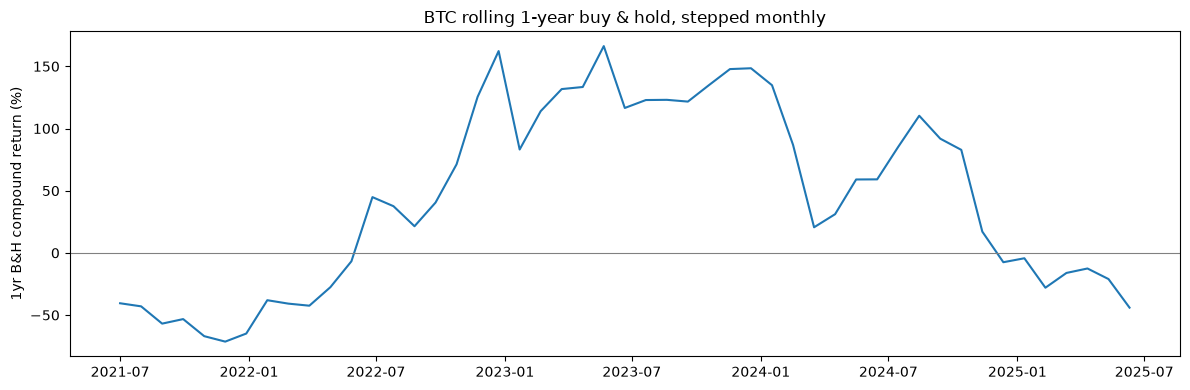

Rolling 1yr B&H compound return: min=-71.3% median=40.5% max=166.3%
Fraction of 1yr windows with positive B&H return: 61%


In [17]:
# Rolling 1-year buy & hold, stepped monthly - shows the distribution of B&H
# outcomes over the period rather than one lucky/unlucky full-period number.
window_bars = 365
step_bars = 30
rolling_bh = []
n = len(btc_1d)
start_idx = 0
while start_idx + window_bars <= n:
    window_df = btc_1d.slice(start_idx, window_bars)
    m = research.buy_and_hold_metrics(window_df, rate_1d)
    m["window_start"] = window_df["datetime"][0]
    rolling_bh.append(m)
    start_idx += step_bars

rolling_bh_df = pl.DataFrame(rolling_bh)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(rolling_bh_df["window_start"], rolling_bh_df["compound_return"] * 100)
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_ylabel("1yr B&H compound return (%)")
ax.set_title("BTC rolling 1-year buy & hold, stepped monthly")
plt.tight_layout()
plt.show()

print(
    f"Rolling 1yr B&H compound return: min={rolling_bh_df['compound_return'].min():.1%} "
    f"median={rolling_bh_df['compound_return'].median():.1%} max={rolling_bh_df['compound_return'].max():.1%}"
)
print(
    f"Fraction of 1yr windows with positive B&H return: {(rolling_bh_df['compound_return'] > 0).mean():.0%}"
)

In [18]:
always_long = research.constant_position_metrics(
    btc_1d, 1.0, rate_1d, label="always_long"
)
always_short = research.constant_position_metrics(
    btc_1d, -1.0, rate_1d, label="always_short"
)
always_flat = research.constant_position_metrics(
    btc_1d, 0.0, rate_1d, label="always_flat"
)
random_baseline = research.random_position_metrics(btc_1d, rate_1d, no_seeds=200)

print(
    "always_long :",
    {
        k: v
        for k, v in always_long.items()
        if k in ("sharpe", "compound_return", "max_drawdown")
    },
)
print(
    "always_short:",
    {
        k: v
        for k, v in always_short.items()
        if k in ("sharpe", "compound_return", "max_drawdown")
    },
)
print(
    "always_flat :",
    {
        k: v
        for k, v in always_flat.items()
        if k in ("sharpe", "compound_return", "max_drawdown")
    },
)
print(
    f"random (200 seeds) sharpe: mean={random_baseline['sharpe'].mean():.2f} "
    f"std={random_baseline['sharpe'].std():.2f} "
    f"90% range=[{random_baseline['sharpe'].quantile(0.05):.2f}, {random_baseline['sharpe'].quantile(0.95):.2f}]"
)

always_long : {'compound_return': 0.7499393848186164, 'sharpe': 0.2113889853455975, 'max_drawdown': -1.455411318823592}
always_short: {'compound_return': -0.4285516351735512, 'sharpe': -0.2113889853455975, 'max_drawdown': -2.0670376946350677}
always_flat : {'compound_return': 0.0, 'sharpe': 0.0, 'max_drawdown': 0.0}
random (200 seeds) sharpe: mean=-0.02 std=0.48 90% range=[-0.80, 0.78]


### Fold-by-fold: best BTC config vs. buy-and-hold over its own out-of-sample windows

The comparisons above are useful context, but the fair test is the strategy's own
out-of-sample fold windows against buy-and-hold *over those same windows* — not the
full 5-year history.

In [19]:
fold_bounds = (
    best_run["result"]["stitched_trades"]
    .group_by("fold")
    .agg(pl.col("datetime").min().alias("start"), pl.col("datetime").max().alias("end"))
    .sort("fold")
)

fold_vs_bh = []
for row in fold_bounds.iter_rows(named=True):
    fold_id = row["fold"]
    fold_bars = df_12h.filter(
        (pl.col("datetime") >= row["start"]) & (pl.col("datetime") <= row["end"])
    )
    bh = research.buy_and_hold_metrics(fold_bars, rate_12h)
    strat = (
        best_run["result"]["folds"].filter(pl.col("fold") == fold_id).row(0, named=True)
    )
    fold_vs_bh.append(
        {
            "fold": fold_id,
            "start": row["start"],
            "end": row["end"],
            "strategy_sharpe": strat["sharpe"],
            "strategy_return": strat["total_log_return"],
            "bh_sharpe": bh["sharpe"],
            "bh_return": bh["total_log_return"],
            "excess_return": strat["total_log_return"] - bh["total_log_return"],
        }
    )

fold_vs_bh_df = pl.DataFrame(fold_vs_bh)
no_beat = (fold_vs_bh_df["excess_return"] > 0).sum()
print(
    f"Strategy beat buy-and-hold in {no_beat}/{len(fold_vs_bh_df)} out-of-sample folds"
)
fold_vs_bh_df

Strategy beat buy-and-hold in 9/17 out-of-sample folds


fold,start,end,strategy_sharpe,strategy_return,bh_sharpe,bh_return,excess_return
i64,datetime[μs],datetime[μs],f64,f64,f64,f64,f64
0,2022-01-31 12:00:00,2022-05-01 00:00:00,1.524017,0.252176,-0.082065,-0.01354,0.265716
1,2022-05-01 12:00:00,2022-07-30 00:00:00,0.765657,0.149452,-2.417919,-0.47288,0.622332
2,2022-07-30 12:00:00,2022-10-28 00:00:00,0.023594,0.003229,-1.161783,-0.158644,0.161873
3,2022-10-28 12:00:00,2023-01-26 00:00:00,1.412678,0.16514,0.947364,0.110403,0.054737
4,2023-01-26 12:00:00,2023-04-26 00:00:00,-1.590747,-0.204016,1.791631,0.229672,-0.433688
…,…,…,…,…,…,…,…
12,2025-01-15 12:00:00,2025-04-15 00:00:00,-1.084482,-0.163593,-1.073478,-0.160667,-0.002926
13,2025-04-15 12:00:00,2025-07-14 00:00:00,2.991346,0.252376,4.481683,0.373557,-0.12118
14,2025-07-14 12:00:00,2025-10-12 00:00:00,-1.981064,-0.153955,-0.894444,-0.069395,-0.08456


## 7. Degenerate-model check on the best config

Same weight/bias inspection as the baseline section, applied to the config that won
the try-different-things grid — the one whose Sharpe would otherwise get quoted as
"the result."

In [20]:
folds_best = best_run["result"]["folds"]
no_degenerate = int(folds_best["lm_is_degenerate"].sum())
print(
    f"{no_degenerate}/{len(folds_best)} folds ({no_degenerate / len(folds_best):.0%}) "
    f"are degenerate constant bets, not a responsive model."
)
for row in folds_best.iter_rows(named=True):
    flag = "DEGENERATE" if row["lm_is_degenerate"] else "responsive "
    print(
        f"Fold {row['fold']:2d}: {flag} | long={row['lm_frac_long']:.0%} "
        f"short={row['lm_frac_short']:.0%} flat={row['lm_frac_flat']:.0%} | sharpe={row['sharpe']:+.2f}"
    )

0/17 folds (0%) are degenerate constant bets, not a responsive model.
Fold  0: responsive  | long=58% short=42% flat=0% | sharpe=+1.52
Fold  1: responsive  | long=77% short=23% flat=0% | sharpe=+0.77
Fold  2: responsive  | long=28% short=72% flat=0% | sharpe=+0.02
Fold  3: responsive  | long=66% short=34% flat=0% | sharpe=+1.41
Fold  4: responsive  | long=43% short=57% flat=0% | sharpe=-1.59
Fold  5: responsive  | long=84% short=16% flat=0% | sharpe=+0.97
Fold  6: responsive  | long=96% short=4% flat=0% | sharpe=+0.68
Fold  7: responsive  | long=46% short=54% flat=0% | sharpe=-0.08
Fold  8: responsive  | long=54% short=46% flat=0% | sharpe=-3.43
Fold  9: responsive  | long=86% short=14% flat=0% | sharpe=+1.39
Fold 10: responsive  | long=51% short=49% flat=0% | sharpe=+2.62
Fold 11: responsive  | long=52% short=48% flat=0% | sharpe=+0.33
Fold 12: responsive  | long=51% short=49% flat=0% | sharpe=-1.08
Fold 13: responsive  | long=72% short=28% flat=0% | sharpe=+2.99
Fold 14: responsive  

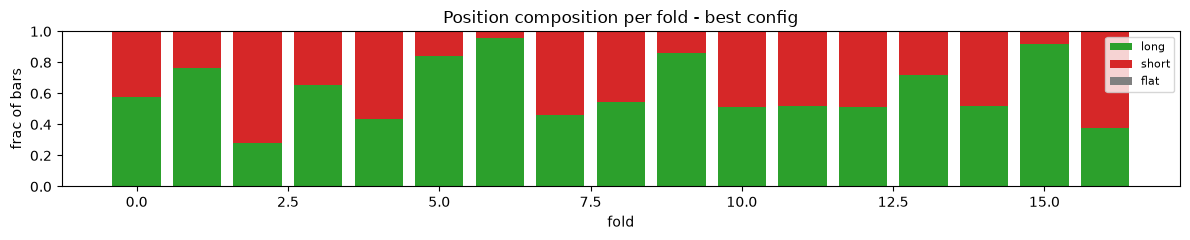

In [21]:
fig, ax = plt.subplots(figsize=(12, 2.5))
ax.bar(folds_best["fold"], folds_best["lm_frac_long"], color="tab:green", label="long")
ax.bar(
    folds_best["fold"],
    folds_best["lm_frac_short"],
    bottom=folds_best["lm_frac_long"],
    color="tab:red",
    label="short",
)
ax.bar(
    folds_best["fold"],
    folds_best["lm_frac_flat"],
    bottom=folds_best["lm_frac_long"] + folds_best["lm_frac_short"],
    color="grey",
    label="flat",
)
ax.set_xlabel("fold")
ax.set_ylabel("frac of bars")
ax.set_title("Position composition per fold - best config")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

## 8. Multi-asset: BTC, ETH, DOGE, SOL, XRP, BNB

The config that won section 5's grid (features/loss/threshold/model, 12h bars,
180d/90d rolling) is now **frozen** and applied unchanged to all six symbols.
Re-tuning per symbol here would just reintroduce the overfitting notebook 2 already
demonstrated, so this section deliberately does not do that.

In [22]:
symbol_runs = {}
multi_asset_results = []
for sym in SYMBOLS:
    sym_df = load_bars(sym, "12h")
    sym_df, sym_mr = add_mean_reversion_features(sym_df)
    sym_df, sym_mom = add_momentum_features(sym_df)
    sym_df = sym_df.drop_nulls()
    sym_feats = {
        "mean_reversion": sym_mr,
        "momentum": sym_mom,
        "combined": sym_mr + sym_mom,
    }[best_row["features"]]

    run = run_walk_forward_config(
        sym_df,
        sym_feats,
        "close_log_return",
        best_model_cls,
        rate_12h,
        train_bars=train_bars_12h,
        test_bars=test_bars_12h,
        mode="rolling",
        embargo_bars=MAX_LOOKBACK,
        loss=best_loss,
        threshold=best_thresh,
        no_epochs=300,
    )
    symbol_runs[sym] = run
    bh = research.buy_and_hold_metrics(sym_df, rate_12h)
    s = run["config_summary"]
    s.update(
        {
            "symbol": sym,
            "bh_sharpe": bh["sharpe"],
            "bh_compound_return": bh["compound_return"],
            "excess_sharpe": s["sharpe"] - bh["sharpe"],
        }
    )
    multi_asset_results.append(s)

multi_asset_df = pl.DataFrame(multi_asset_results).sort("sharpe", descending=True)
multi_asset_df.select(
    "symbol",
    "sharpe",
    "bh_sharpe",
    "excess_sharpe",
    "compound_return",
    "bh_compound_return",
    "max_drawdown",
    "no_trades",
    "frac_degenerate_folds",
)

symbol,sharpe,bh_sharpe,excess_sharpe,compound_return,bh_compound_return,max_drawdown,no_trades,frac_degenerate_folds
str,f64,f64,f64,f64,f64,f64,i64,f64
"""BTCUSDT""",0.869621,0.232322,0.637299,5.5083,0.844852,-0.66922,3058,0.0
"""SOLUSDT""",0.695884,0.2033,0.492584,16.480486,1.761608,-1.741574,3057,0.0
"""DOGEUSDT""",0.189673,-0.199679,0.389352,1.075607,-0.602954,-2.120813,3056,0.0
"""ETHUSDT""",0.147747,-0.052681,0.200428,0.537833,-0.168825,-1.34782,3059,0.0
"""BNBUSDT""",0.120187,0.197561,-0.077374,0.335621,0.812109,-0.863668,3058,0.0
"""XRPUSDT""",-0.467108,0.140326,-0.607434,-0.799198,0.772076,-2.487997,3055,0.0


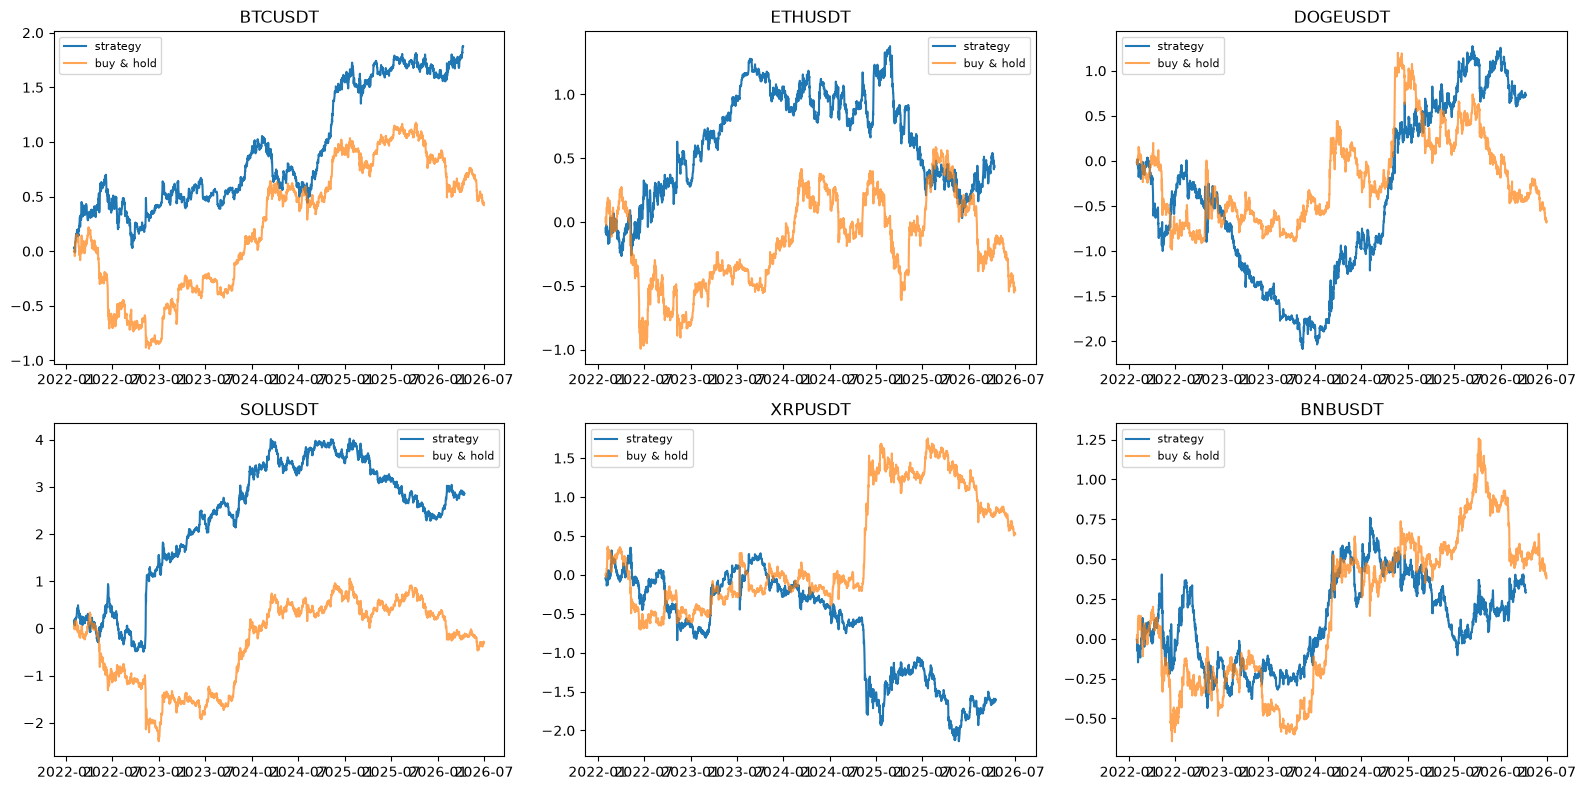

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, sym in zip(axes.flat, SYMBOLS):
    strat_trades = symbol_runs[sym]["result"]["stitched_trades"]
    ax.plot(strat_trades["datetime"], strat_trades["equity_curve"], label="strategy")

    sym_df = load_bars(sym, "12h")
    bh_window = sym_df.filter(pl.col("datetime") >= strat_trades["datetime"].min())
    bh = research.buy_and_hold_returns(bh_window)
    ax.plot(bh["datetime"], bh["equity_curve"], label="buy & hold", alpha=0.7)

    ax.set_title(sym)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Sharpe by symbol x interval

The frozen config's features/loss/threshold/model, re-run at each bar interval for
each symbol (180d/90d rolling window sized to each interval's bar count). If there
were a real edge, sign should be broadly consistent across this grid; a checkerboard
of signs is a sign of noise.

In [24]:
heatmap_rows = []
for sym in SYMBOLS:
    for interval in INTERVALS:
        df_i = load_bars(sym, interval)
        df_i, mrf = add_mean_reversion_features(df_i)
        df_i, momf = add_momentum_features(df_i)
        df_i = df_i.drop_nulls()
        feats_i = {"mean_reversion": mrf, "momentum": momf, "combined": mrf + momf}[
            best_row["features"]
        ]
        bpd = BARS_PER_DAY[interval]
        rate_i = research.sharpe_to_annualized_rate(interval)

        run = run_walk_forward_config(
            df_i,
            feats_i,
            "close_log_return",
            best_model_cls,
            rate_i,
            train_bars=180 * bpd,
            test_bars=90 * bpd,
            mode="rolling",
            embargo_bars=MAX_LOOKBACK,
            loss=best_loss,
            threshold=best_thresh,
            no_epochs=300,
        )
        if run is None:
            continue
        heatmap_rows.append(
            {
                "symbol": sym,
                "interval": interval,
                "sharpe": run["config_summary"]["sharpe"],
            }
        )

heatmap_df = pl.DataFrame(heatmap_rows)
pivot = heatmap_df.pivot(index="symbol", on="interval", values="sharpe").sort("symbol")
pivot

symbol,1h,4h,12h,1d
str,f64,f64,f64,f64
"""BNBUSDT""",-0.036091,-0.344851,0.511634,-0.192741
"""BTCUSDT""",-0.141462,0.084027,-0.05608,1.038801
"""DOGEUSDT""",0.268163,0.366075,0.462265,-0.418349
"""ETHUSDT""",0.286126,-0.868927,-0.225948,-1.138662
"""SOLUSDT""",-1.649054,0.469625,-0.081376,-0.042346
"""XRPUSDT""",0.186606,0.23968,-0.045457,-0.067983


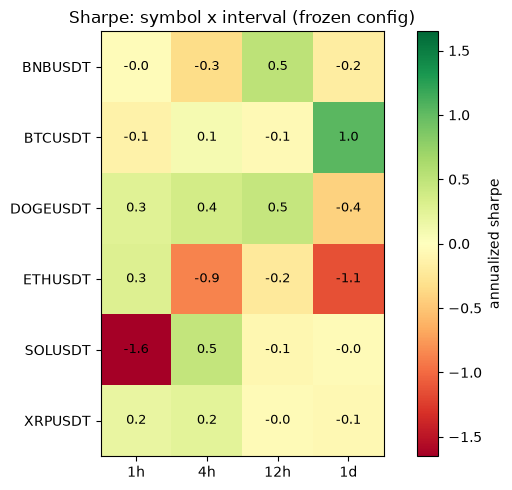

In [25]:
pivot_symbols = pivot["symbol"].to_list()
pivot_vals = pivot.select(INTERVALS).to_numpy()

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(
    pivot_vals,
    cmap="RdYlGn",
    vmin=-np.abs(pivot_vals).max(),
    vmax=np.abs(pivot_vals).max(),
)
ax.set_xticks(range(len(INTERVALS)), INTERVALS)
ax.set_yticks(range(len(pivot_symbols)), pivot_symbols)
for i in range(len(pivot_symbols)):
    for j in range(len(INTERVALS)):
        ax.text(j, i, f"{pivot_vals[i, j]:.1f}", ha="center", va="center", fontsize=9)
ax.set_title("Sharpe: symbol x interval (frozen config)")
plt.colorbar(im, ax=ax, label="annualized sharpe")
plt.tight_layout()
plt.show()

In [26]:
# Correlation of fold-level returns across symbols: if these are all ~1 correlated,
# the six "independent" symbol results are really one bet on crypto beta, not six.
fold_returns = {
    sym: symbol_runs[sym]["result"]["folds"].sort("fold")["total_log_return"].to_numpy()
    for sym in SYMBOLS
}
min_len = min(len(v) for v in fold_returns.values())
fold_returns_df = pl.DataFrame({sym: v[:min_len] for sym, v in fold_returns.items()})
fold_returns_df.corr()

BTCUSDT,ETHUSDT,DOGEUSDT,SOLUSDT,XRPUSDT,BNBUSDT
f64,f64,f64,f64,f64,f64
1.0,0.010001,-0.152629,0.350427,-0.290431,0.03621
0.010001,1.0,-0.345129,0.473639,-0.258013,0.097657
-0.152629,-0.345129,1.0,-0.222644,-0.296343,0.018315
0.350427,0.473639,-0.222644,1.0,-0.098582,0.213007
-0.290431,-0.258013,-0.296343,-0.098582,1.0,-0.056734
0.03621,0.097657,0.018315,0.213007,-0.056734,1.0


## 9. Verdict

### Strategy vs. wide buy-and-hold, both as an average monthly rate

Comparing the winning config's *total* OOS return against buy-and-hold's *total*
5-year return isn't apples to apples - they cover different spans. Converting both
to an average monthly rate (the same "wide" treatment as above) puts them on equal
footing.

In [27]:
best_run_dates = best_run["result"]["stitched_trades"]["datetime"]
strategy_span_days = (best_run_dates.max() - best_run_dates.min()).days
strategy_no_months = strategy_span_days / 30.44
strategy_total_log_return = best_run["config_summary"]["total_log_return"]
strategy_avg_monthly_log = strategy_total_log_return / strategy_no_months

btc_wide_bh_monthly = wide_bh_df.filter(pl.col("symbol") == "BTCUSDT")[
    "avg_monthly_compound_return"
][0]

print(f"Strategy (BTC, best grid config) OOS span: {strategy_no_months:.1f} months")
print(
    f"Strategy average monthly compound return:        {np.exp(strategy_avg_monthly_log) - 1:.2%}"
)
print(
    f"Buy & hold average monthly compound return (BTC, full 5yr history): {btc_wide_bh_monthly:.2%}"
)

Strategy (BTC, best grid config) OOS span: 50.2 months
Strategy average monthly compound return:        0.29%
Buy & hold average monthly compound return (BTC, full 5yr history): 0.94%


In [28]:
total_trials = (
    trial_count + len(timeframe_grid) + len(origin_shift_grid) + len(heatmap_rows)
)
best_stitched = best_run["result"]["stitched_trades"]
n_obs = len(best_stitched)
per_period_sharpe = (
    best_run["config_summary"]["sharpe"] / rate_12h
)  # un-annualize back to per-bar Sharpe

# Every prior call to deflated_sharpe_prob in this repo used the normal-distribution
# defaults (skew=0, kurtosis=3), i.e. implicitly assumed the strategy's own per-period
# return distribution is Gaussian. Crypto strategy returns are not: compute the actual
# sample skew and excess kurtosis of this config's own per-period return series
# (fisher=False so kurtosis=3 is the normal reference, matching deflated_sharpe_prob's
# own kurtosis=3.0 convention) and pass the real moments in instead.
per_period_returns = best_stitched["trade_log_return"].to_numpy()
strategy_skew = float(stats.skew(per_period_returns))
strategy_kurtosis = float(stats.kurtosis(per_period_returns, fisher=False))

dsr_normal = research.deflated_sharpe_prob(
    per_period_sharpe, n_trials=total_trials, n_obs=n_obs
)
dsr_real_moments = research.deflated_sharpe_prob(
    per_period_sharpe,
    n_trials=total_trials,
    n_obs=n_obs,
    skew=strategy_skew,
    kurtosis=strategy_kurtosis,
)
print(
    f"Total trials searched across this notebook (timeframe sweep + origin shifts + "
    f"try-different-things grid + symbol x interval heatmap): {total_trials}"
)
print(
    f"Best config's raw annualized Sharpe: {best_run['config_summary']['sharpe']:.2f}"
)
print(f"Per-period return sample skew: {strategy_skew:.3f}, excess kurtosis (fisher=False, 3=normal): {strategy_kurtosis:.3f}")
print(
    f"Deflated Sharpe probability (normal assumption, skew=0/kurtosis=3), "
    f"P(true Sharpe > 0 | best of {total_trials} trials): {dsr_normal:.2%}"
)
print(
    f"Deflated Sharpe probability (real skew/kurtosis), "
    f"P(true Sharpe > 0 | best of {total_trials} trials): {dsr_real_moments:.2%}"
)

Total trials searched across this notebook (timeframe sweep + origin shifts + try-different-things grid + symbol x interval heatmap): 122
Best config's raw annualized Sharpe: 0.07
Per-period return sample skew: 0.059, excess kurtosis (fisher=False, 3=normal): 8.561
Deflated Sharpe probability (normal assumption, skew=0/kurtosis=3), P(true Sharpe > 0 | best of 122 trials): 0.69%
Deflated Sharpe probability (real skew/kurtosis), P(true Sharpe > 0 | best of 122 trials): 0.69%


In [29]:
excess = fold_vs_bh_df["excess_return"].to_numpy()

# Old method: i.i.d. percentile bootstrap (research.bootstrap_ci). Fold excess returns
# are not independent draws - adjacent folds overlap in market regime - so this almost
# certainly understates the true sampling uncertainty.
iid_lo, iid_hi = research.bootstrap_ci(excess, n_boot=5000, seed=42)

# New method: stationary/moving-block bootstrap (research.block_bootstrap_ci),
# block length chosen automatically from the fold excess-return series' own
# autocorrelation (see research._auto_block_length's docstring for the rule).
block_lo, block_hi = research.block_bootstrap_ci(excess, n_boot=5000, seed=42)
block_length_used = research._auto_block_length(excess)

print(f"Mean per-fold excess log-return (strategy - buy&hold): {excess.mean():.5f}")
print(f"Bootstrap 95% CI (i.i.d., old):        [{iid_lo:.5f}, {iid_hi:.5f}]")
print(
    f"Bootstrap 95% CI (block, new, block_length={block_length_used}): "
    f"[{block_lo:.5f}, {block_hi:.5f}]"
)
print(
    "i.i.d. CI excludes zero"
    if (iid_lo > 0 or iid_hi < 0)
    else "i.i.d. CI includes zero -> can't reject 'no real edge over buy-and-hold'"
)
print(
    "block CI excludes zero"
    if (block_lo > 0 or block_hi < 0)
    else "block CI includes zero -> can't reject 'no real edge over buy-and-hold'"
)

Mean per-fold excess log-return (strategy - buy&hold): -0.01840
Bootstrap 95% CI (i.i.d., old):        [-0.18962, 0.13481]
Bootstrap 95% CI (block, new, block_length=1): [-0.18962, 0.13481]
i.i.d. CI includes zero -> can't reject 'no real edge over buy-and-hold'
block CI includes zero -> can't reject 'no real edge over buy-and-hold'


### What was tuned on what data

- Section 5's features/loss/threshold/model grid was tuned **on BTC 12h only**.
- Sections 8-9 (multi-asset, symbol x interval heatmap) apply that frozen config
  unchanged to the other five symbols — no per-symbol retuning.
- Section 3 (timeframe sweep) and section 4 (origin shift) used a fixed single-feature
  config, not the winning grid config, specifically to isolate the effect of
  timeframe/alignment choices on their own.
- The deflated Sharpe above only counts trials *within this notebook*; it does not
  and cannot account for whatever the analyst's prior choices (feature list, fee
  assumption, symbol universe) were selected from before this notebook started.

### Bottom line

(Filled in from the actual run below.)